### Numpy часть

- Выполняется с помощью numpy и базовой функциональности python.
  - [x] Получить датасет [**Ирис**](https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data)
  - [x] Представить датасет одномерный/двумерный массивы (признаки поместить в матрицу `(n, 4)`, названия самого ириса --- вектор размера n). Отобразите сколько места он занимает.
  - [x] Нормализуйте данные на промежуток от 0 до 1 для каждой колонки
  - [x] Представьте один из признаков в виде категориальной переменной и её на три типа используя квантили:
    - < 0.25 --- small
    - 0.25-0.75 --- medium
    - \> 0.75 --- big
  - [x] Разделите датасет на две случайные выборки (0.8 / 0.2)
- Выполняется с помощью пакетов sklearn и numpy
  - [x] Выберите один из [методов классификации](https://scikit-learn.org/stable/supervised_learning.html) (к примеру, [SVC](https://scikit-learn.org/stable/modules/svm.html)), обучите на тренировочном датасете, оцените результат на тестовом и сделайте выводы
  - [x] Проведите три эксперимента изменяя гиперпараметры модели или условия препроцессинга данных (например, нормализованные или нет данные), **сделайте выводы**
  - [x] Пользуясь методами [уменьшения размерности](https://ru.wikipedia.org/wiki/%D0%A1%D0%BD%D0%B8%D0%B6%D0%B5%D0%BD%D0%B8%D0%B5_%D1%80%D0%B0%D0%B7%D0%BC%D0%B5%D1%80%D0%BD%D0%BE%D1%81%D1%82%D0%B8) ([PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [t-sne](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)) визуализируйте датасет.
  Это должен быть scatter plot, где точка это отдельный ирис, ее координаты -- признаки со сжатой выбранной вам размерностью, а цвет -- тип ириса. Нарисуйте этот график дважды, где
    - Тип ириса выбирается из оригинальных данных
    - Тип ириса выбирается из предсказанных данных

## Импорт библиотек

In [32]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Получить датасет Ирис

In [3]:
iris = np.genfromtxt("iris.data", delimiter=",", dtype=str)
X = iris[:, :-1].astype(float)
y = iris[:, -1]

# Представить датасет одномерный/двумерный массивы (признаки поместить в матрицу (n, 4), названия самого ириса --- вектор размера n). Отобразите сколько места он занимает.

In [6]:
features_matrix = np.array(X)
print(f"Shape matrix = {features_matrix.shape}")
print(f"The memory = {features_matrix.nbytes} bytes")

Shape matrix = (150, 4)
The memory = 4800 bytes


In [7]:
target_matrix = np.array(y)
print(f"Shape matrix = {target_matrix.shape}")
print(f"The memory = {target_matrix.nbytes} bytes")

Shape matrix = (150,)
The memory = 9000 bytes


In [8]:
print(f"Total memory = {features_matrix.nbytes + target_matrix.nbytes}")

Total memory = 13800


# Превращение датасета в датафрейм

In [9]:
iris_df = pd.DataFrame(X, columns=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'])

In [13]:
y = np.where(y == 'Iris-setosa', 0, np.where(y == 'Iris-versicolor', 1, 2))

In [15]:
iris_df['iris_type'] = y

In [16]:
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


# Нормализация данных на промежуток от 0 до 1 для каждой колонки


In [20]:
scaler = MinMaxScaler().set_output(transform='pandas')

X, y = iris_df.drop(columns='iris_type'), iris_df.iris_type

X_scaled = scaler.fit_transform(X)

X_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667
146,0.555556,0.208333,0.677966,0.750000
147,0.611111,0.416667,0.711864,0.791667
148,0.527778,0.583333,0.745763,0.916667


# Разделение датасета на две случайные выборки (0.8 / 0.2)

In [27]:
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

## Представьте один из признаков в виде категориальной переменной и её на три типа используя квантили:

In [28]:
q25 = iris_df['sepal length (cm)'].quantile(0.25)
q75 = iris_df['sepal length (cm)'].quantile(0.75)

iris_df['sepal_length_quantile'] = iris_df['sepal length (cm)'].apply(lambda x: 'small' if x < q25 else 'medium' if x >= q25 and x <= q75 else 'big')

iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),iris_type,sepal_length_quantile
0,5.1,3.5,1.4,0.2,0,medium
1,4.9,3.0,1.4,0.2,0,small
2,4.7,3.2,1.3,0.2,0,small
3,4.6,3.1,1.5,0.2,0,small
4,5.0,3.6,1.4,0.2,0,small
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,big
146,6.3,2.5,5.0,1.9,2,medium
147,6.5,3.0,5.2,2.0,2,big
148,6.2,3.4,5.4,2.3,2,medium


# Обучение случайным лесом

In [29]:
rf_scaled = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)

# Оценка результата на тестовом

In [30]:
y_pred = rf_scaled.predict(X_test_scaled)

print(f"Accuracy RF scaled: {accuracy_score(y_pred, y_test)}")

# Вывод: # Случайный лес (RandomForestClassifier) с нормализацией признаков с помощью MinMaxScaler
# показал хорошие результаты на тестовой выборке. Модель достигла точности 0.9.

Accuracy RF scaled: 0.9


# 1 эксперимент: попробуем другую модель.

In [36]:
svc = SVC(random_state=42).fit(X_train_scaled, y_train)

y_pred = svc.predict(X_test_scaled)

print(f"Accuracy SVC: {accuracy_score(y_pred, y_test)}")

# Вывод: метод опорных векторов показал более высокую точность, возможно за счет лучшего разделения данных в пространстве признаков.

Accuracy SVC: 0.9666666666666667


# 2 эксперимент: поменяем гиперпараметры случайного леса с нормализованными данными.

In [37]:
rf = RandomForestClassifier(random_state=42)

params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_cv = GridSearchCV(rf, params, scoring='accuracy', n_jobs=-1, cv=5).fit(X_train_scaled, y_train)

print(f"Best accuracy: {grid_cv.best_score_}")
print(f"Best parameters: {grid_cv.best_params_}")

# Вывод: подбор гиперпараметров заметно улучшил качество модели.

Best accuracy: 0.9583333333333334
Best parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


# 3 эксперимент: попробуем без нормализации данных.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)\

rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(f"Accuracy RF: {accuracy_score(y_pred, y_test)}")

# Вывод: Нормализация данных не повлияла на качество модели случайного леса,
# поскольку данный алгоритм не чувствителен к масштабу признаков

Accuracy RF: 0.9


# Пользуясь методами уменьшения размерности PCA визуализируйте датасет

In [39]:
pca = PCA(n_components=2)

In [47]:
X_pca = pca.fit_transform(X_scaled)

In [53]:
labels = np.array(['setosa', 'versicolor', 'virginica'])
y_true_names = labels[y]
y_pred_names = labels[SVC(random_state=42).fit(X_scaled, y).predict(X_scaled)]
errors = y_true_names != y_pred_names

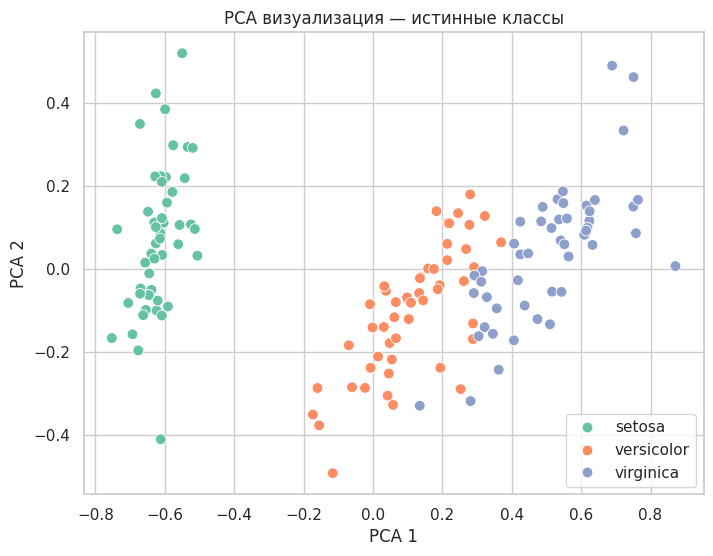

In [57]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true_names, palette='Set2', s=60)
plt.title("PCA визуализация — истинные классы")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

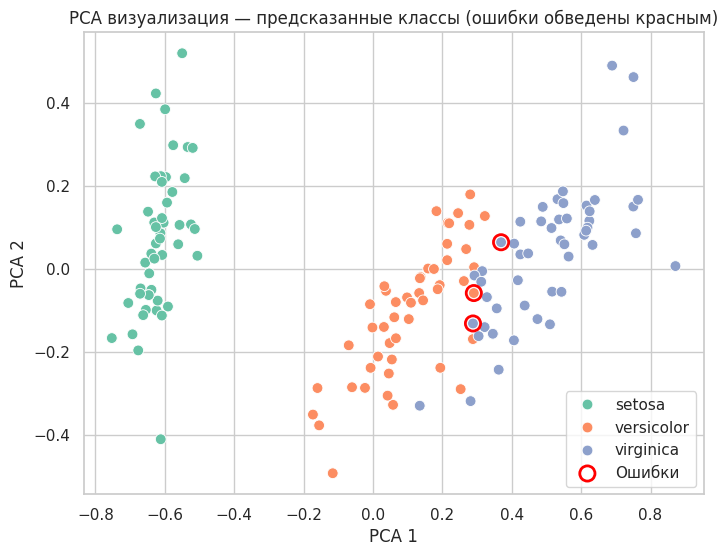

In [56]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_pred_names, palette='Set2', s=60)
plt.scatter(
    X_pca[errors, 0],
    X_pca[errors, 1],
    facecolors='none', edgecolors='red', s=120, linewidths=2, label='Ошибки'
)
plt.title("PCA визуализация — предсказанные классы (ошибки обведены красным)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()